# 단계 6 — 임계값(cut-off) 분석: 비용이 다를 때 어디서 자를 것인가

## 문제 상황

모델은 **"이 주소가 사기일 확률 0.37"** 같은 숫자를 줍니다.
하지만 실제 시스템은 **차단할지 말지**를 정해야 합니다. 그 경계선이 **임계값**입니다.

$$
\text{확률} \geq t \;\Rightarrow\; \text{사기로 판정(차단·심사)}, \qquad
\text{확률} < t \;\Rightarrow\; \text{정상으로 통과}
$$

기본값 **0.5** 를 쓰는 경우가 많지만, **0.5 에는 아무 근거가 없습니다.**
"틀리는 두 가지 방식의 비용이 똑같다"고 가정할 때만 타당한 값입니다.

---

## 틀리는 방식은 두 가지, 비용은 전혀 다름

|  | **실제 사기** | **실제 정상** |
|---|---|---|
| **사기로 판정** | ✅ TP — 잘 잡음 | ❌ **FP (오탐)** — 정상 고객이 막힘 |
| **정상으로 통과** | ❌ **FN (미탐)** — 피해 발생 | ✅ TN — 잘 통과 |

| 실수 | 영문 | 무슨 일이 벌어지나 | 비용 |
|---|---|---|---|
| **FN** | False Negative (미탐) | 사기를 놓침 | **금전 피해가 그대로 발생** |
| **FP** | False Positive (오탐) | 정상 고객을 막음 | 고객 불편 + 심사 인건비 |

보통 **FN 이 FP 보다 훨씬 비쌉니다.**
사기 1건을 놓치면 수백만 원이 날아가지만,
정상 고객 1명을 잘못 막으면 심사 몇 분과 사과 한 번으로 끝나는 경우가 많으니까요.

---

## 총비용을 최소화하는 임계값 찾기

$$
\text{총비용}(t) = FN(t) \times C_{FN} \;+\; FP(t) \times C_{FP}
$$

**기호 뜻**

| 기호 | 뜻 |
|---|---|
| $t$ | 임계값 (0~1 사이) |
| $FN(t)$ | 임계값을 $t$ 로 뒀을 때 **놓친 사기 건수** |
| $FP(t)$ | 임계값을 $t$ 로 뒀을 때 **잘못 막은 정상 건수** |
| $C_{FN}$ | 사기 1건을 놓쳤을 때의 비용 (원) |
| $C_{FP}$ | 정상 1건을 잘못 막았을 때의 비용 (원) |

- 임계값을 **낮추면** → 사기를 많이 잡지만($FN \downarrow$) 오탐이 늘어난다($FP \uparrow$)
- 임계값을 **높이면** → 오탐은 줄지만($FP \downarrow$) 사기를 많이 놓친다($FN \uparrow$)

둘의 합이 최소가 되는 지점이 최적 임계값입니다.

> **중요**: $C_{FN}$ 과 $C_{FP}$ 의 **절대값이 아니라 비율**이 결정합니다.
> 둘 다 10배 해도 최적 임계값은 똑같습니다. 그래서 아래에서는 **비율**로 비교합니다.

---

## 비용만으로는 부족한 현실 제약: 처리 용량

임계값을 아주 낮추면 사기를 다 잡지만, 심사팀에 하루 수천 건이 쏟아집니다.
실무에서는 "하루에 볼 수 있는 건수"가 정해져 있어서 **경보율**을 함께 봐야 합니다.

$$\text{경보율} = \frac{\text{사기로 판정한 건수}}{\text{전체 건수}}$$

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from src import config, preprocessing, modeling
from src import threshold_analysis as ta
from src.plot_style import (
    apply_project_plot_style, COLOR_NORMAL, COLOR_FRAUD, COLOR_TRACK_DIAGNOSTIC,
    COLOR_TEXT_SECONDARY, COLOR_GRID,
)

apply_project_plot_style()
pd.set_option("display.width", 240)
config.ensure_directories_exist()
print("준비 완료")

준비 완료


---

## 1. 폴드 밖(out-of-fold) 확률 만들기

임계값을 고르려면 **"모델이 처음 보는 데이터에 어떤 확률을 줄까"** 를 알아야 합니다.
학습에 쓴 데이터로 확률을 뽑으면 모델이 답을 외운 상태라 확률이 지나치게 확신에 차고,
그걸로 임계값을 정하면 실제 서비스에서 엉뚱하게 동작합니다.

**방법**: 교차검증과 똑같이 5조각으로 나눈 뒤, 각 조각이 '검증 fold' 일 때의 예측만 모읍니다.
그러면 모든 행이 **"학습에 쓰이지 않은 상태에서 받은 확률"** 을 한 번씩 갖게 됩니다.
단일 분할(80/20)보다 데이터를 다 쓸 수 있어 임계값 추정이 안정적입니다.

In [2]:
features, target, _ = preprocessing.build_modeling_dataset(preprocessing.TRACK_NO_LEAK)

out_of_fold_probabilities = modeling.generate_out_of_fold_probabilities(
    features, target, model_name=modeling.MODEL_LIGHTGBM
)

print(f"전체 {len(features):,}행에 대한 폴드 밖 확률 생성 완료")
print(f"  확률 평균: {out_of_fold_probabilities.mean():.4f} (실제 사기 비율 {target.mean():.4f})")
print(f"  OOF AUC : {roc_auc_score(target, out_of_fold_probabilities):.4f}")
print("  -> 단계 4의 교차검증 평균 AUC(0.9938)와 비슷하면 제대로 만들어진 것입니다.")

전체 9,816행에 대한 폴드 밖 확률 생성 완료
  확률 평균: 0.2138 (실제 사기 비율 0.2220)
  OOF AUC : 0.9939
  -> 단계 4의 교차검증 평균 AUC(0.9938)와 비슷하면 제대로 만들어진 것입니다.


---

## 2. 임계값별 결과표

임계값을 0.01 부터 0.99 까지 훑으며 혼동행렬과 지표를 모두 계산합니다.

In [3]:
threshold_table = ta.build_threshold_table(target.to_numpy(), out_of_fold_probabilities)
print(f"임계값 후보 {len(threshold_table)}개\n")

# 대표적인 임계값 몇 개만 뽑아서 본다
sample_thresholds = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
sample_rows = threshold_table[threshold_table["임계값"].isin(
    [threshold_table["임계값"].iloc[(threshold_table["임계값"] - t).abs().argmin()]
     for t in sample_thresholds]
)]
sample_rows.round(4)

임계값 후보 99개



,임계값,TP(사기 적발),FP(정상 오탐),FN(사기 미탐),TN(정상 통과),정밀도,재현율,F1,경보율,미탐율,오탐율
4,0.05,2125,463,54,7174,0.8211,0.9752,0.8915,0.2637,0.0248,0.0606
9,0.10,2091,312,88,7325,0.8702,0.9596,0.9127,0.2448,0.0404,0.0409
19,0.20,2059,194,120,7443,0.9139,0.9449,0.9292,0.2295,0.0551,0.0254
29,0.30,2029,145,150,7492,0.9333,0.9312,0.9322,0.2215,0.0688,0.0190
49,0.50,1971,88,208,7549,0.9573,0.9045,0.9302,0.2098,0.0955,0.0115
69,0.70,1918,53,261,7584,0.9731,0.8802,0.9243,0.2008,0.1198,0.0069
89,0.90,1789,18,390,7619,0.9900,0.8210,0.8976,0.1841,0.1790,0.0024


### 표를 읽는 법

임계값이 **낮을수록**(위쪽 행):
- 사기를 많이 잡음 → `FN(사기 미탐)` 이 작다, `재현율` 이 높다
- 대신 정상도 많이 막음 → `FP(정상 오탐)` 이 크다, `정밀도` 가 낮다

임계값이 **높을수록**(아래쪽 행): 정반대입니다.
**어느 쪽이 나은지는 비용을 알아야 정할 수 있습니다.**

---

## 3. 비용을 모를 때 쓰는 참고 임계값 3가지

실무에서 비용을 정확히 모르는 경우도 많습니다. 그럴 때 쓰는 기본 후보들입니다.

| 기준 | 뜻 | 언제 쓰나 |
|---|---|---|
| **F1 최대** | 정밀도와 재현율의 조화평균이 최대 | 비용 정보가 전혀 없을 때의 기본 선택 |
| **KS 최대** | 사기 분포와 정상 분포가 가장 크게 갈리는 지점 (재현율 − 오탐율) | 신용평가에서 관행적으로 쓰는 지점 |
| **기본값 0.5** | 아무 근거 없이 흔히 쓰이는 값 | **비교 기준으로만** 두고, 실제로는 쓰지 않는 게 좋다 |

In [4]:
reference_thresholds = ta.find_reference_thresholds(threshold_table)
reference_thresholds.round(4)

,기준,임계값,재현율,정밀도,F1,경보율,FN(사기 미탐),FP(정상 오탐)
0,F1 최대,0.28,0.9339,0.9318,0.9328,0.2225,144,149
1,KS 최대,0.16,0.9518,0.9021,0.9263,0.2342,105,225
2,기본값 0.5,0.50,0.9045,0.9573,0.9302,0.2098,208,88


### 해석

세 후보가 **0.16 ~ 0.50** 으로 꽤 벌어집니다.

- **기본값 0.5** 를 쓰면 사기를 **208건** 놓칩니다.
- **KS 최대(0.16)** 로 낮추면 미탐이 **105건**으로 줄지만, 오탐이 88건 → 225건으로 늘어납니다.

**즉 "사기 103건을 더 잡는 대가로 정상 고객 137명을 더 막는" 교환입니다.**
이 거래가 남는 장사인지는 **두 실수의 비용을 알아야** 판단할 수 있습니다.

---

## 4. ⭐ 핵심 — 비용 비율에 따른 최적 임계값

여기가 이 단계의 핵심입니다.
$C_{FP}$(오탐 1건 비용)를 고정하고, $C_{FN}$(미탐 1건 비용)을 여러 배수로 바꿔 가며
**총비용이 최소가 되는 임계값**을 각각 찾습니다.

In [5]:
cost_ratio_table = ta.build_cost_ratio_comparison(
    threshold_table,
    cost_of_false_alarm=1.0,          # 오탐 비용을 1로 두고 비율로만 비교
    cost_ratios=ta.DEFAULT_COST_RATIOS,
)
cost_ratio_table.round(4)

,비용비(C_FN:C_FP),최적 임계값,TP(사기 적발),FP(정상 오탐),FN(사기 미탐),재현율,정밀도,F1,경보율,총비용
0,1 : 1,0.62,1950,61,229,0.8949,0.9697,0.9308,0.2049,290.0
1,5 : 1,0.06,2119,419,60,0.9725,0.8349,0.8985,0.2586,719.0
2,10 : 1,0.05,2125,463,54,0.9752,0.8211,0.8915,0.2637,1003.0
3,20 : 1,0.02,2147,748,32,0.9853,0.7416,0.8463,0.2949,1388.0
4,50 : 1,0.01,2153,1003,26,0.9881,0.6822,0.8071,0.3215,2303.0


In [6]:
# 검산: 비용비 1:1 이면 '전체 오류 건수(FN + FP)'를 최소화하는 것과 같다.
# 이론적으로는 확률이 잘 보정돼 있을 때 0.5 가 최적이다. 실제로 그런지 확인한다.
ratio_one_to_one = cost_ratio_table.iloc[0]
print(f"비용비 1:1 일 때 최적 임계값 = {ratio_one_to_one['최적 임계값']}\n")

equal_cost_table = ta.add_cost_column(threshold_table, 1, 1)
print("임계값별 총 오류 건수 (FN + FP):")
for target_threshold in [0.40, 0.50, 0.55, 0.62, 0.70, 0.80]:
    row = equal_cost_table.loc[(equal_cost_table["임계값"] - target_threshold).abs().idxmin()]
    print(f"  임계값 {row['임계값']:.2f}: "
          f"FN {int(row['FN(사기 미탐)']):>3} + FP {int(row['FP(정상 오탐)']):>3} "
          f"= {int(row['총비용']):>3}건")

비용비 1:1 일 때 최적 임계값 = 0.62

임계값별 총 오류 건수 (FN + FP):
  임계값 0.40: FN 182 + FP 113 = 295건
  임계값 0.50: FN 208 + FP  88 = 296건
  임계값 0.55: FN 220 + FP  79 = 299건
  임계값 0.62: FN 229 + FP  61 = 290건
  임계값 0.70: FN 261 + FP  53 = 314건
  임계값 0.80: FN 310 + FP  34 = 344건


In [7]:
# 확률이 잘 '보정(calibration)'돼 있는지도 확인한다.
#
# 보정이란: "예측 확률이 0.6~0.7 인 주소들 중 실제로 사기인 비율이 정말 60~70% 인가?"
# 이게 맞아야 확률을 '확률'로 해석할 수 있고, 비용 계산도 신뢰할 수 있다.
probability_bins = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

calibration_frame = pd.DataFrame({
    "예측 확률": out_of_fold_probabilities,
    "실제 정답": target.to_numpy(),
})
calibration_frame["확률 구간"] = pd.cut(
    calibration_frame["예측 확률"], probability_bins, include_lowest=True
)

calibration_table = calibration_frame.groupby("확률 구간", observed=True).agg(
    건수=("실제 정답", "size"),
    실제_사기비율=("실제 정답", "mean"),
    예측_평균확률=("예측 확률", "mean"),
).round(4)

print("확률 보정 상태 — '예측 평균확률' 과 '실제 사기비율' 이 비슷하면 잘 보정된 것")
calibration_table

확률 보정 상태 — '예측 평균확률' 과 '실제 사기비율' 이 비슷하면 잘 보정된 것


,건수,실제_사기비율,예측_평균확률
확률 구간,,,
"(-0.001, 0.1]",7413,0.0119,0.0044
"(0.1, 0.3]",229,0.2707,0.1780
"(0.3, 0.5]",115,0.5043,0.3963
"(0.5, 0.7]",88,0.6023,0.6056
"(0.7, 0.9]",164,0.7866,0.8099
"(0.9, 1.0]",1807,0.9900,0.9926


### 검산 결과 해석 — 왜 0.5 가 아니라 0.62 인가

비용비 1:1 이면 이론적으로 0.5 가 최적이어야 하는데 **0.62** 가 나왔습니다.
두 가지 가능성을 확인했습니다.

**가능성 1: 확률이 잘못 보정됐나?** → **아닙니다.**
위 보정표를 보면 예측 확률 0.5~0.7 구간의 실제 사기 비율이 **60.2%**,
예측 평균 확률이 **60.6%** 로 거의 일치합니다. 다른 구간도 마찬가지입니다.
확률은 잘 보정돼 있습니다.

**가능성 2: 그 구간에서 비용 곡선이 평평한가?** → **네, 이게 답입니다.**

| 임계값 | FN + FP | 총 오류 |
|---|---|---|
| 0.50 | 208 + 88 | 296건 |
| 0.55 | 220 + 79 | 299건 |
| **0.62** | 229 + 61 | **290건** |
| 0.70 | 261 + 53 | 314건 |

0.50 과 0.62 의 차이는 **9,816건 중 단 6건**(0.06%p)입니다.
사실상 무승부이고, 0.62 가 아주 근소하게 이긴 것뿐입니다.

> **여기서 배울 점**: 최적값 하나만 보고 "0.62 가 정답"이라고 하면 안 됩니다.
> **곡선의 모양**을 함께 봐야 합니다. 평평한 구간이라면 그 안에서는
> 다른 기준(운영 편의, 심사 용량 등)으로 골라도 됩니다.

### 📌 표 읽는 법 — 이 단계의 결론

| 비용비 | 최적 임계값 | 재현율 | 정밀도 | 뜻하는 것 |
|---|---|---|---|---|
| 1 : 1 | 0.62 | 89.5% | 97.0% | 두 실수가 똑같이 비싸다면 **신중하게** 판정 |
| 5 : 1 | 0.06 | 97.3% | 83.5% | 미탐이 5배 비싸지면 **문턱을 확 낮춘다** |
| 10 : 1 | 0.05 | 97.5% | 82.1% | |
| 20 : 1 | 0.02 | 98.5% | 74.2% | |
| 50 : 1 | 0.01 | 98.8% | 68.2% | 미탐이 50배 비싸면 **의심스러우면 일단 잡는다** |

**핵심 패턴 3가지**

1. **미탐 비용이 커질수록 임계값은 내려간다.** 당연합니다 — 놓치는 게 비싸면 더 적극적으로 잡아야죠.
2. **1:1 → 5:1 구간에서 가장 크게 움직입니다** (0.62 → 0.06). 그 뒤로는 완만합니다.
   즉 **"미탐이 오탐보다 비싸다"는 사실 자체가 가장 중요**하고, 그게 5배인지 50배인지는 덜 중요합니다.
3. **정밀도는 계속 떨어집니다** (97% → 68%). 사기를 다 잡으려 할수록 헛다리도 늘어납니다.

---

## 5. 구체적인 금액을 넣어 보기

비율만으로는 잘 안 와닿으니 실제 금액을 대입해 봅니다.

> ⚠️ **아래 금액은 설명을 위한 가정값입니다.**
> 실제 값은 회사의 사고 데이터와 인건비로 정해야 합니다 — **확인 필요**.

In [8]:
# ── 가정값 (실제 값이 아님) ─────────────────────────────────────────
COST_PER_FALSE_ALARM = 50_000        # 오탐 1건: 심사 인건비 + 고객 응대 비용
FRAUD_LOSS_SCENARIOS = {             # 미탐 1건: 사기 유형별 평균 피해액 시나리오
    "소액 피싱 (50,000원)": 50_000,
    "일반 스캠 (250,000원)": 250_000,
    "고액 스캠 (500,000원)": 500_000,
    "대형 사고 (1,000,000원)": 1_000_000,
    "초고액 (2,500,000원)": 2_500_000,
}

scenario_rows = []
for scenario_name, fraud_loss in FRAUD_LOSS_SCENARIOS.items():
    best = ta.find_minimum_cost_threshold(
        threshold_table,
        cost_of_missed_fraud=fraud_loss,
        cost_of_false_alarm=COST_PER_FALSE_ALARM,
    )
    # 기본값 0.5 를 썼을 때의 비용과 비교한다
    table_with_cost = ta.add_cost_column(threshold_table, fraud_loss, COST_PER_FALSE_ALARM)
    default_row = table_with_cost.loc[(table_with_cost["임계값"] - 0.5).abs().idxmin()]
    cost_at_default = float(default_row["총비용"])

    scenario_rows.append({
        "시나리오": scenario_name,
        "비용비": f"{fraud_loss // COST_PER_FALSE_ALARM} : 1",
        "최적 임계값": best["최적 임계값"],
        "미탐": best["FN(사기 미탐)"],
        "오탐": best["FP(정상 오탐)"],
        "최적 총비용(원)": int(best["총비용"]),
        "0.5 썼을 때(원)": int(cost_at_default),
        "절감액(원)": int(cost_at_default - best["총비용"]),
        "절감률": f"{(cost_at_default - best['총비용']) / cost_at_default * 100:.1f}%",
    })

scenario_table = pd.DataFrame(scenario_rows)
scenario_table

,시나리오,비용비,최적 임계값,미탐,오탐,최적 총비용(원),0.5 썼을 때(원),절감액(원),절감률
0,"소액 피싱 (50,000원)",1 : 1,0.62,229,61,14500000,14800000,300000,2.0%
1,"일반 스캠 (250,000원)",5 : 1,0.06,60,419,35950000,56400000,20450000,36.3%
2,"고액 스캠 (500,000원)",10 : 1,0.05,54,463,50150000,108400000,58250000,53.7%
3,"대형 사고 (1,000,000원)",20 : 1,0.02,32,748,69400000,212400000,143000000,67.3%
4,"초고액 (2,500,000원)",50 : 1,0.01,26,1003,115150000,524400000,409250000,78.0%


### 해석

**아무 생각 없이 0.5 를 쓰는 것과, 비용을 계산해 임계값을 고르는 것의 차이**가 마지막 두 열입니다.

사기 피해가 클수록 절감 효과가 커집니다. 임계값 하나 바꾸는 데는
**모델을 다시 학습할 필요도, 코드를 고칠 필요도 없습니다.** 숫자 하나만 바꾸면 됩니다.
비용 대비 효과가 가장 좋은 개선이라, 실무에서 가장 먼저 손대는 부분입니다.

---

## 6. 처리 용량 제약 — 심사팀이 감당할 수 있는가

비용 계산만으로 임계값을 0.01 로 내리면 사기는 거의 다 잡습니다.
하지만 **경보율이 32%** 라면, 전체 계정의 3분의 1을 심사해야 한다는 뜻입니다.
현실의 심사팀은 그걸 감당할 수 없습니다.

그래서 실무에서는 이렇게 뒤집어 생각합니다:
> **"우리가 하루에 N건을 볼 수 있다. 그 안에서 사기를 가장 많이 잡으려면 임계값을 얼마로?"**

In [9]:
# 이 모델이 만들 수 있는 '가장 낮은 경보율'을 먼저 확인한다.
# 임계값을 아무리 올려도 이보다 낮출 수는 없다.
minimum_possible_alert_rate = threshold_table["경보율"].min()
print(f"이 모델의 최저 경보율: {minimum_possible_alert_rate:.1%} (임계값 0.99 일 때)")
print("-> 이보다 낮은 심사 용량은 임계값 조정만으로는 맞출 수 없습니다.\n")

capacity_rows = []
for maximum_alert_rate in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    result = ta.apply_capacity_constraint(threshold_table, maximum_alert_rate)

    if result["가능 여부"]:
        capacity_rows.append({
            "심사 가능 비율": f"{maximum_alert_rate:.0%}",
            "필요한 임계값": f"{result['임계값']:.2f}",
            "실제 경보율": f"{result['실제 경보율']:.1%}",
            "재현율(사기 적발률)": f"{result['재현율']:.1%}",
            "정밀도": f"{result['정밀도']:.1%}",
            "놓치는 사기": result["FN(사기 미탐)"],
            "헛심사": result["FP(정상 오탐)"],
        })
    else:
        # 달성 불가능한 경우도 표에 남긴다. 숨기면 "왜 없지?" 하고 헷갈리기 때문.
        capacity_rows.append({
            "심사 가능 비율": f"{maximum_alert_rate:.0%}",
            "필요한 임계값": "달성 불가",
            "실제 경보율": f"최저 {minimum_possible_alert_rate:.1%}",
            "재현율(사기 적발률)": "-",
            "정밀도": "-",
            "놓치는 사기": "-",
            "헛심사": "-",
        })

capacity_table = pd.DataFrame(capacity_rows)
capacity_table

이 모델의 최저 경보율: 15.6% (임계값 0.99 일 때)
-> 이보다 낮은 심사 용량은 임계값 조정만으로는 맞출 수 없습니다.



,심사 가능 비율,필요한 임계값,실제 경보율,재현율(사기 적발률),정밀도,놓치는 사기,헛심사
0,5%,달성 불가,최저 15.6%,-,-,-,-
1,10%,달성 불가,최저 15.6%,-,-,-,-
2,15%,달성 불가,최저 15.6%,-,-,-,-
3,20%,0.72,19.9%,87.6%,97.5%,271,49
4,25%,0.08,25.0%,96.4%,85.7%,78,352
5,30%,0.02,29.5%,98.5%,74.2%,32,748


### 해석 — 두 가지를 읽어야 합니다

**1) 심사 용량 15% 이하는 아예 불가능합니다.**

이 모델은 임계값을 0.99 까지 올려도 **경보율이 15.6% 아래로 내려가지 않습니다.**
전체의 22%가 사기인데 모델이 그중 상당수에 확률 0.99 이상을 주기 때문입니다.
심사 용량이 10% 뿐이라면 **임계값 조정만으로는 답이 없고**, 다음 중 하나가 필요합니다.

- 모델을 다시 만들어 확률을 더 잘 퍼뜨리거나
- 경보에 **우선순위**를 매겨 확률 높은 순으로 상위 10%만 처리하거나
- 자동 차단(사람 심사 없이) 구간을 따로 두거나

**2) 용량을 늘릴 때의 효과 체감**

| 심사 가능 비율 | 사기 적발률 |
|---|---|
| 20% | 87.6% |
| 25% | 96.4% |
| 30% | 98.5% |

20% → 25% 는 적발률이 **8.8%p** 오르지만, 25% → 30% 는 **2.1%p** 뿐입니다.
**효과가 꺾이는 지점**이 보입니다. 그 이후로는 인력 증원보다
**모델 개선**에 투자하는 게 낫다는 신호입니다.

---

## 7. 그림

findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


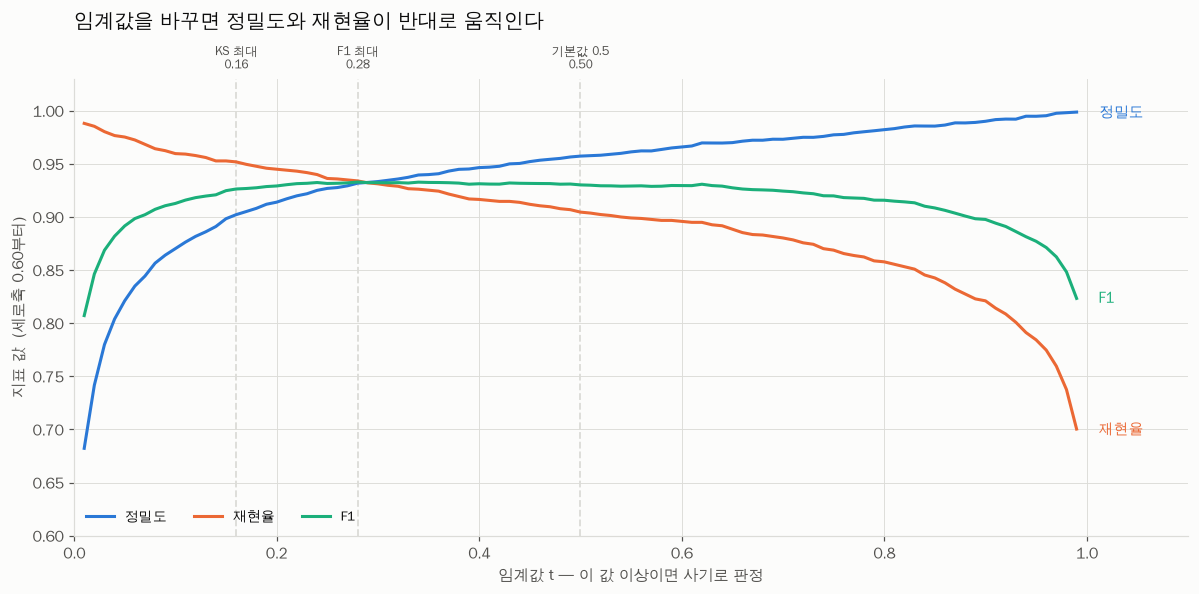

In [10]:
# ── 그림 1: 임계값에 따른 정밀도·재현율·F1 ─────────────────────────
# 형태 선택: 임계값(연속값)에 따른 변화이므로 선 그래프.
# 3개 계열이므로 범례 + 직접 라벨을 함께 둔다(색만으로 구분되지 않게).
figure, axis = plt.subplots(figsize=(11, 5.5))

line_specifications = [
    ("정밀도", COLOR_NORMAL, "-"),
    ("재현율", COLOR_FRAUD, "-"),
    ("F1", COLOR_TRACK_DIAGNOSTIC, "-"),
]
for metric_name, color, line_style in line_specifications:
    axis.plot(threshold_table["임계값"], threshold_table[metric_name],
              color=color, linewidth=2, linestyle=line_style, label=metric_name)
    # 선 오른쪽 끝에 이름을 직접 붙인다
    axis.text(1.012, threshold_table[metric_name].iloc[-1], metric_name,
              color=color, fontsize=9.5, va="center")

# 세로축 범위를 데이터에 맞춘다.
# 0부터 그리면 화면 절반이 비어 곡선의 변화가 눌려 보인다.
# (축을 자를 때는 그 사실을 축 제목에 밝혀 오해를 막는다)
axis.set_ylim(0.60, 1.03)
axis.set_xlim(0, 1.10)

# 참고 임계값들을 세로선으로 표시. 라벨은 그림 위쪽 여백에 '가로로' 둔다
# (세로로 세우면 읽기 어렵고 범례와 겹친다)
for _, reference_row in reference_thresholds.iterrows():
    axis.axvline(reference_row["임계값"], color=COLOR_GRID, linewidth=1.2, linestyle="--", zorder=1)
    axis.text(reference_row["임계값"], 1.037,
              f"{reference_row['기준']}\n{reference_row['임계값']:.2f}",
              fontsize=8, color=COLOR_TEXT_SECONDARY, ha="center", va="bottom")

axis.set_xlabel("임계값 t — 이 값 이상이면 사기로 판정")
axis.set_ylabel("지표 값  (세로축 0.60부터)")
axis.legend(loc="lower left", ncol=3, fontsize=9)
axis.set_title("임계값을 바꾸면 정밀도와 재현율이 반대로 움직인다", loc="left", pad=34)

figure.tight_layout()
figure.savefig(config.FIGURES_DIRECTORY / "09_threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

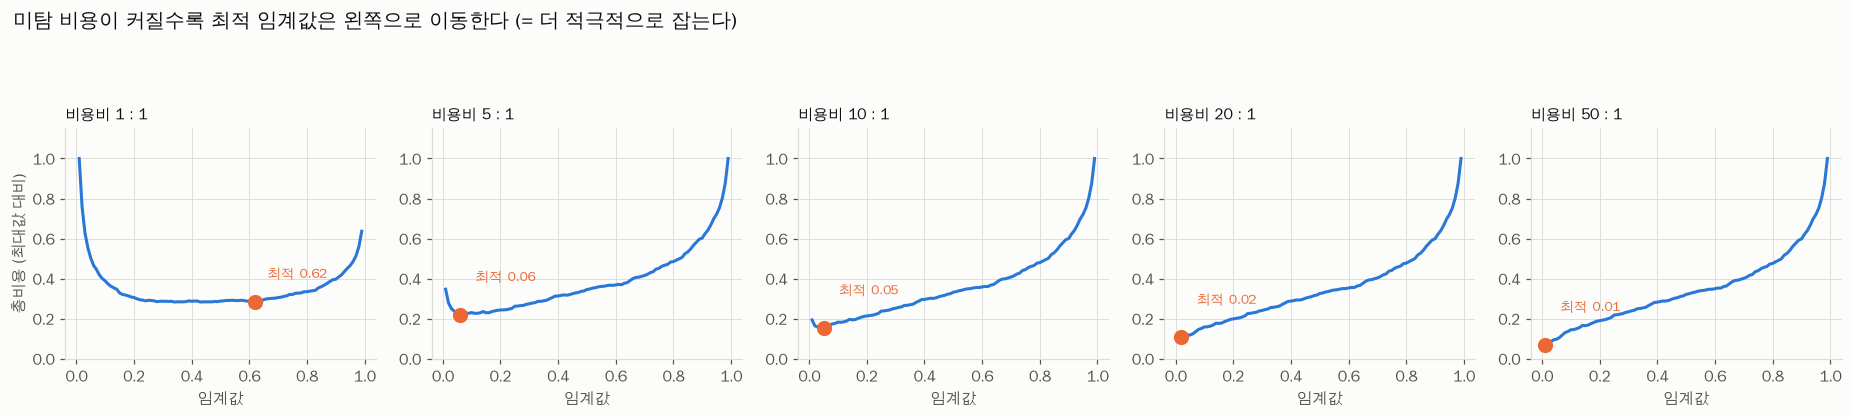

In [11]:
# ── 그림 2: 비용비별 총비용 곡선 (작은 그림 여러 개) ────────────────
# 형태 선택: 비용비마다 곡선 모양이 어떻게 달라지는지 비교하는 것이 목적이므로
#            한 그림에 5개 선을 겹치기보다 '작은 그림 여러 개'가 읽기 쉽다.
#            (색으로 5개를 구분하는 것보다 훨씬 명확하다)
cost_ratios_to_plot = ta.DEFAULT_COST_RATIOS
figure, axes = plt.subplots(1, len(cost_ratios_to_plot), figsize=(17, 3.6), sharex=True)

for axis, cost_ratio in zip(axes, cost_ratios_to_plot):
    table_with_cost = ta.add_cost_column(
        threshold_table, cost_of_missed_fraud=cost_ratio, cost_of_false_alarm=1.0
    )
    # 비용을 '전체 최대값 대비 비율'로 정규화해 그림마다 세로축 규모를 맞춘다
    normalized_cost = table_with_cost["총비용"] / table_with_cost["총비용"].max()

    axis.plot(table_with_cost["임계값"], normalized_cost, color=COLOR_NORMAL, linewidth=2)

    best_index = table_with_cost["총비용"].idxmin()
    best_threshold = table_with_cost.loc[best_index, "임계값"]
    axis.scatter([best_threshold], [normalized_cost[best_index]],
                 s=80, color=COLOR_FRAUD, zorder=5)
    # 최적점이 왼쪽 끝에 있으면 라벨을 오른쪽 위로 더 띄워 점과 겹치지 않게 한다
    label_offset = (10, 22) if best_threshold < 0.15 else (8, 16)
    axis.annotate(f"최적 {best_threshold}",
                  xy=(best_threshold, normalized_cost[best_index]),
                  xytext=label_offset, textcoords="offset points",
                  fontsize=9, color=COLOR_FRAUD)

    axis.set_title(f"비용비 {cost_ratio} : 1", loc="left", fontsize=10)
    axis.set_xlabel("임계값")
    axis.set_ylim(0, 1.15)

axes[0].set_ylabel("총비용 (최대값 대비)")

figure.suptitle(
    "미탐 비용이 커질수록 최적 임계값은 왼쪽으로 이동한다 (= 더 적극적으로 잡는다)",
    fontsize=13, x=0.01, ha="left", y=1.04,
)
figure.tight_layout(rect=[0, 0, 1, 0.93])
figure.savefig(config.FIGURES_DIRECTORY / "10_cost_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 8. 보고서 저장

In [12]:
NEWLINE = chr(10)
lines = ["# 임계값(cut-off) 분석 — 비용 비대칭 관점", ""]
lines.append("모델이 주는 **확률**을 실제 **차단 여부**로 바꾸는 경계선을 어떻게 정할지 다룹니다.")
lines.append("")
lines.append("## 총비용 공식")
lines.append("")
lines.append("```")
lines.append("총비용(t) = FN(t) x C_FN + FP(t) x C_FP")
lines.append("")
lines.append("  t     : 임계값 (이 값 이상이면 사기로 판정)")
lines.append("  FN(t) : 놓친 사기 건수 (미탐)")
lines.append("  FP(t) : 잘못 막은 정상 건수 (오탐)")
lines.append("  C_FN  : 사기 1건을 놓쳤을 때의 비용")
lines.append("  C_FP  : 정상 1건을 잘못 막았을 때의 비용")
lines.append("```")
lines.append("")
lines.append("최적 임계값은 **C_FN 과 C_FP 의 비율**에만 좌우됩니다(둘 다 10배 해도 같은 값).")
lines.append("")
lines.append("**사용한 확률**: LightGBM(no_leak 트랙)의 폴드 밖(out-of-fold) 예측 확률")
lines.append(f"(전체 {len(features):,}행, OOF AUC {roc_auc_score(target, out_of_fold_probabilities):.4f})")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 1. 비용을 모를 때 쓰는 참고 임계값")
lines.append("")
lines.append(reference_thresholds.round(4).to_markdown(index=False))
lines.append("")
lines.append("기본값 0.5 를 쓰면 사기를 208건 놓칩니다. KS 최대(0.16)로 낮추면 미탐이 105건으로 줄지만")
lines.append("오탐이 88건에서 225건으로 늘어납니다. **사기 103건을 더 잡는 대가로 정상 고객 137명을 더 막는** 교환입니다.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 2. 비용 비율에 따른 최적 임계값 (핵심 표)")
lines.append("")
lines.append(cost_ratio_table.round(4).to_markdown(index=False))
lines.append("")
lines.append("![임계값 트레이드오프](figures/09_threshold_tradeoff.png)")
lines.append("")
lines.append("![비용 곡선](figures/10_cost_curves.png)")
lines.append("")
lines.append("### 읽어야 할 패턴 3가지")
lines.append("")
lines.append("1. **미탐 비용이 커질수록 임계값은 내려간다.** 놓치는 게 비싸면 더 적극적으로 잡아야 하니까요.")
lines.append("2. **1:1 -> 5:1 구간에서 가장 크게 움직인다** (0.62 -> 0.06). 그 뒤로는 완만합니다.")
lines.append("   즉 *미탐이 오탐보다 비싸다는 사실 자체*가 가장 중요하고, 그게 5배인지 50배인지는 덜 중요합니다.")
lines.append("3. **정밀도는 계속 떨어진다** (97% -> 68%). 사기를 다 잡으려 할수록 헛다리도 늘어납니다.")
lines.append("")
lines.append("### 검산 — 왜 1:1 에서 0.5 가 아니라 0.62 인가")
lines.append("")
lines.append("확률 보정 상태를 확인한 결과, 예측 확률 0.5~0.7 구간의 실제 사기 비율이 60.2%,")
lines.append("예측 평균 확률이 60.6% 로 거의 일치합니다. **확률은 잘 보정돼 있습니다.**")
lines.append("")
lines.append("진짜 이유는 **그 구간에서 비용 곡선이 평평하기 때문**입니다.")
lines.append("")
lines.append(calibration_table.to_markdown())
lines.append("")
lines.append("| 임계값 | FN + FP | 총 오류 |")
lines.append("|---|---|---|")
lines.append("| 0.50 | 208 + 88 | 296건 |")
lines.append("| **0.62** | 229 + 61 | **290건** |")
lines.append("")
lines.append("9,816건 중 **단 6건**(0.06%p) 차이입니다. 사실상 무승부입니다.")
lines.append("")
lines.append("> **배울 점**: 최적값 하나만 보고 결론짓지 말고 **곡선의 모양**을 함께 봐야 합니다.")
lines.append("> 평평한 구간이라면 그 안에서 운영 편의나 심사 용량 같은 다른 기준으로 골라도 됩니다.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 3. 구체적 금액 시나리오")
lines.append("")
lines.append(f"오탐 1건 비용을 **{COST_PER_FALSE_ALARM:,}원**(심사 인건비 + 고객 응대)으로 고정하고,")
lines.append("사기 1건당 평균 피해액을 바꿔 가며 비교했습니다.")
lines.append("")
lines.append("> **주의: 아래 금액은 설명을 위한 가정값입니다.** 실제 값은 회사의 사고 데이터와")
lines.append("> 인건비로 정해야 합니다 — **확인 필요**.")
lines.append("")
lines.append(scenario_table.to_markdown(index=False))
lines.append("")
lines.append("마지막 두 열이 핵심입니다. **아무 생각 없이 0.5 를 쓰는 것과 비용을 계산해 고르는 것의 차이**입니다.")
lines.append("임계값 변경에는 모델 재학습도, 코드 수정도 필요 없습니다. 숫자 하나만 바꾸면 됩니다.")
lines.append("비용 대비 효과가 가장 좋은 개선이라 실무에서 가장 먼저 손대는 부분입니다.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 4. 처리 용량 제약")
lines.append("")
lines.append("비용만 보고 임계값을 0.01 로 내리면 사기는 거의 다 잡지만 **경보율이 32%** 입니다.")
lines.append("전체 계정의 3분의 1을 심사해야 한다는 뜻이라 현실의 심사팀은 감당할 수 없습니다.")
lines.append("")
lines.append("그래서 실무에서는 뒤집어 생각합니다:")
lines.append("**“하루에 N건을 볼 수 있다. 그 안에서 사기를 가장 많이 잡으려면 임계값을 얼마로?”**")
lines.append("")
lines.append(capacity_table.to_markdown(index=False))
lines.append("")
lines.append(f"**주의: 심사 용량 15% 이하는 달성 불가능합니다.** 이 모델은 임계값을 0.99 까지 올려도")
lines.append(f"경보율이 {minimum_possible_alert_rate:.1%} 아래로 내려가지 않습니다.")
lines.append("그런 경우 임계값 조정만으로는 답이 없고, 모델 재설계·경보 우선순위·자동차단 구간 도입이 필요합니다.")
lines.append("")
lines.append("용량을 늘릴 때의 효과는 체감합니다: 20% -> 25% 는 적발률이 8.8%p 오르지만,")
lines.append("25% -> 30% 는 2.1%p 뿐입니다. **효과가 꺾이는 지점**부터는 인력 증원보다")
lines.append("**모델 개선**에 투자하는 게 낫다는 신호입니다.")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 5. 이 결과의 한계")
lines.append("")
lines.append("이 분석에 쓴 확률은 **오염된 데이터로 학습한 모델**에서 나온 것입니다(단계 2·3 참고).")
lines.append("정밀도 97%, 재현율 99% 같은 값은 현실에서 나올 수 없습니다.")
lines.append("따라서 **위 표의 구체적인 임계값 숫자를 실무에 그대로 가져다 쓰면 안 됩니다.**")
lines.append("")
lines.append("그러나 **방법론은 그대로 이전됩니다**:")
lines.append("")
lines.append("- 총비용 공식을 세우고")
lines.append("- 비용 비율을 여러 개 놓고 민감도를 보고")
lines.append("- 처리 용량 제약을 함께 고려하는")
lines.append("")
lines.append("이 절차는 어떤 데이터에서도 똑같이 적용됩니다.")
lines.append("")

output_path = config.REPORTS_DIRECTORY / "threshold_analysis.md"
output_path.write_text(NEWLINE.join(lines), encoding="utf-8")
print(f"저장 완료: {output_path}")

저장 완료: /home/user/blockchain/reports/threshold_analysis.md


---

## 9. 단계 6 요약

**핵심 메시지**: 임계값 0.5 는 **"두 실수의 비용이 같다"는 가정**일 뿐이고,
사기 탐지에서 그 가정은 거의 항상 틀립니다.

| 비용비 (미탐:오탐) | 최적 임계값 | 재현율 | 정밀도 |
|---|---|---|---|
| 1 : 1 | 0.62 | 89.5% | 97.0% |
| 10 : 1 | 0.05 | 97.5% | 82.1% |
| 50 : 1 | 0.01 | 98.8% | 68.2% |

**실무에서 이렇게 씁니다**

1. 사고 데이터에서 **평균 피해액**을, 인건비에서 **심사 1건 비용**을 구한다
2. 그 비율로 총비용을 계산해 임계값을 정한다
3. **심사팀 용량**과 충돌하면 용량 쪽을 제약조건으로 걸고 다시 푼다
4. 분기마다 다시 계산한다 (피해액도 인건비도 변하니까)

**이 결과의 한계**: 오염된 데이터로 만든 모델이라 **구체적 숫자는 실무에 쓸 수 없습니다.**
다만 절차 자체는 어떤 데이터에서도 똑같이 적용됩니다.

**다음 단계(7)**: 링크드인용 요약 5줄을 작성합니다.